# Signal types classification

В некоторых веществах в результате прохождения через них заряженных частиц возникают короткие вспышки света – сцинтилляции. Вещества, излучающие свет под действием ионизирующего излучения, называют сцинтилляторами.

Сцинтилляции отличны от остальных видов свечения, образующегося во время взаимодействия частиц с веществом тем, что они возникают вследствие электронных переходов внутри так называемых центров свечения. Такими центрами свечения могут служить, например, атомы, ионы, молекулы. Каждая вспышка вызвана отдельной заряженной частицей и состоит из большого количества (10^3 − 10^6) фотонов.

При получении данных, эксперименты с которыми производились в настоящей работе, был использован сцинтилляционный детектор, на основе органических кристаллов паратерфенила. Перспективность сцинтилляторов на основе органических кристаллов паратерфенила в регистрации нейтронного излучения в присутствии гамма-фона обуславливает большое содержание атомов водорода в вышеупомянутых элементах систем детектирования. Вызвано это тем, что для регистрации нейтронов используют эффект упругого рассеяния нейтронов с ядром.

При упругом рассеянии нейтронов на ядрах, наблюдается эффект отдачи кинетической энергии. Таким образом, вещество, из которого должен быть сделан сцинтиллятор, выбирается в соответствии с тем требованием, чтобы кинетическая энергия была максимально возможной. Наибольшее значение данной энергии наблюдается для ядер водорода.
Именно поэтому высокое содержание водорода в используемом сцинтилляторе играет весомую роль в процессе детектирования излучения, содержащего в себе нейтроны.

## Подготовка и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
%matplotlib inline

In [2]:
dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset.shape

(23479, 505)

In [3]:
dataset.iloc[:3, :10]

,0,1,2,3,4,5,6,7,8,9
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824


In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB


## Исследование и анализ данных

### Очистка данных

In [6]:
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)

In [7]:
dataset.columns = list(range(500))

In [8]:
print(f"Форма данных после очистки: {dataset.shape}")

Форма данных после очистки: (23479, 500)


### Базовая информация о данных

In [9]:
print("Статистическое описание данных:")
dataset.describe().round(2)

Статистическое описание данных:


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
count,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,...,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00
mean,14822.97,14822.96,14822.97,14822.99,14823.00,14822.98,14822.97,14822.95,14822.96,14822.97,...,14822.33,14822.32,14822.27,14822.17,14822.26,14822.32,14822.28,14822.28,14822.29,14822.28
std,2.81,2.83,2.84,2.85,2.83,2.84,2.83,2.83,2.85,2.81,...,3.36,3.37,3.34,3.33,3.29,3.23,3.27,3.25,3.25,3.24
min,14812.00,14812.00,14812.00,14811.00,14812.00,14812.00,14812.00,14811.00,14812.00,14809.00,...,14800.00,14798.00,14802.00,14796.00,14802.00,14801.00,14798.00,14804.00,14800.00,14802.00
25%,14821.00,14821.00,14821.00,14821.00,14821.00,14821.00,14821.00,14821.00,14821.00,14821.00,...,14820.00,14820.00,14820.00,14820.00,14820.00,14820.00,14820.00,14820.00,14820.00,14820.00
50%,14823.00,14823.00,14823.00,14823.00,14823.00,14823.00,14823.00,14823.00,14823.00,14823.00,...,14823.00,14823.00,14823.00,14822.00,14823.00,14823.00,14823.00,14823.00,14823.00,14823.00
75%,14824.00,14824.00,14825.00,14825.00,14825.00,14824.00,14824.00,14824.00,14824.00,14824.00,...,14824.00,14824.00,14824.00,14824.00,14824.00,14824.00,14824.00,14824.00,14824.00,14824.00
max,14834.00,14835.00,14834.00,14835.00,14834.00,14835.00,14835.00,14833.00,14834.00,14834.00,...,14836.00,14835.00,14834.00,14836.00,14833.00,14834.00,14833.00,14834.00,14833.00,14835.00


In [10]:
missing = dataset.isnull().sum().sum()
print(f"Всего пропущенных значений: {missing}")

Всего пропущенных значений: 0


In [11]:
print("Минимальное значение во всем датасете:", dataset.values.min())
print("Максимальное значение во всем датасете:", dataset.values.max())

Минимальное значение во всем датасете: 0
Максимальное значение во всем датасете: 14838


Случайно выбранные сигналы: [np.int64(501), np.int64(1510), np.int64(3296), np.int64(3492), np.int64(6087), np.int64(9504), np.int64(11994), np.int64(13473), np.int64(17797), np.int64(19177)]


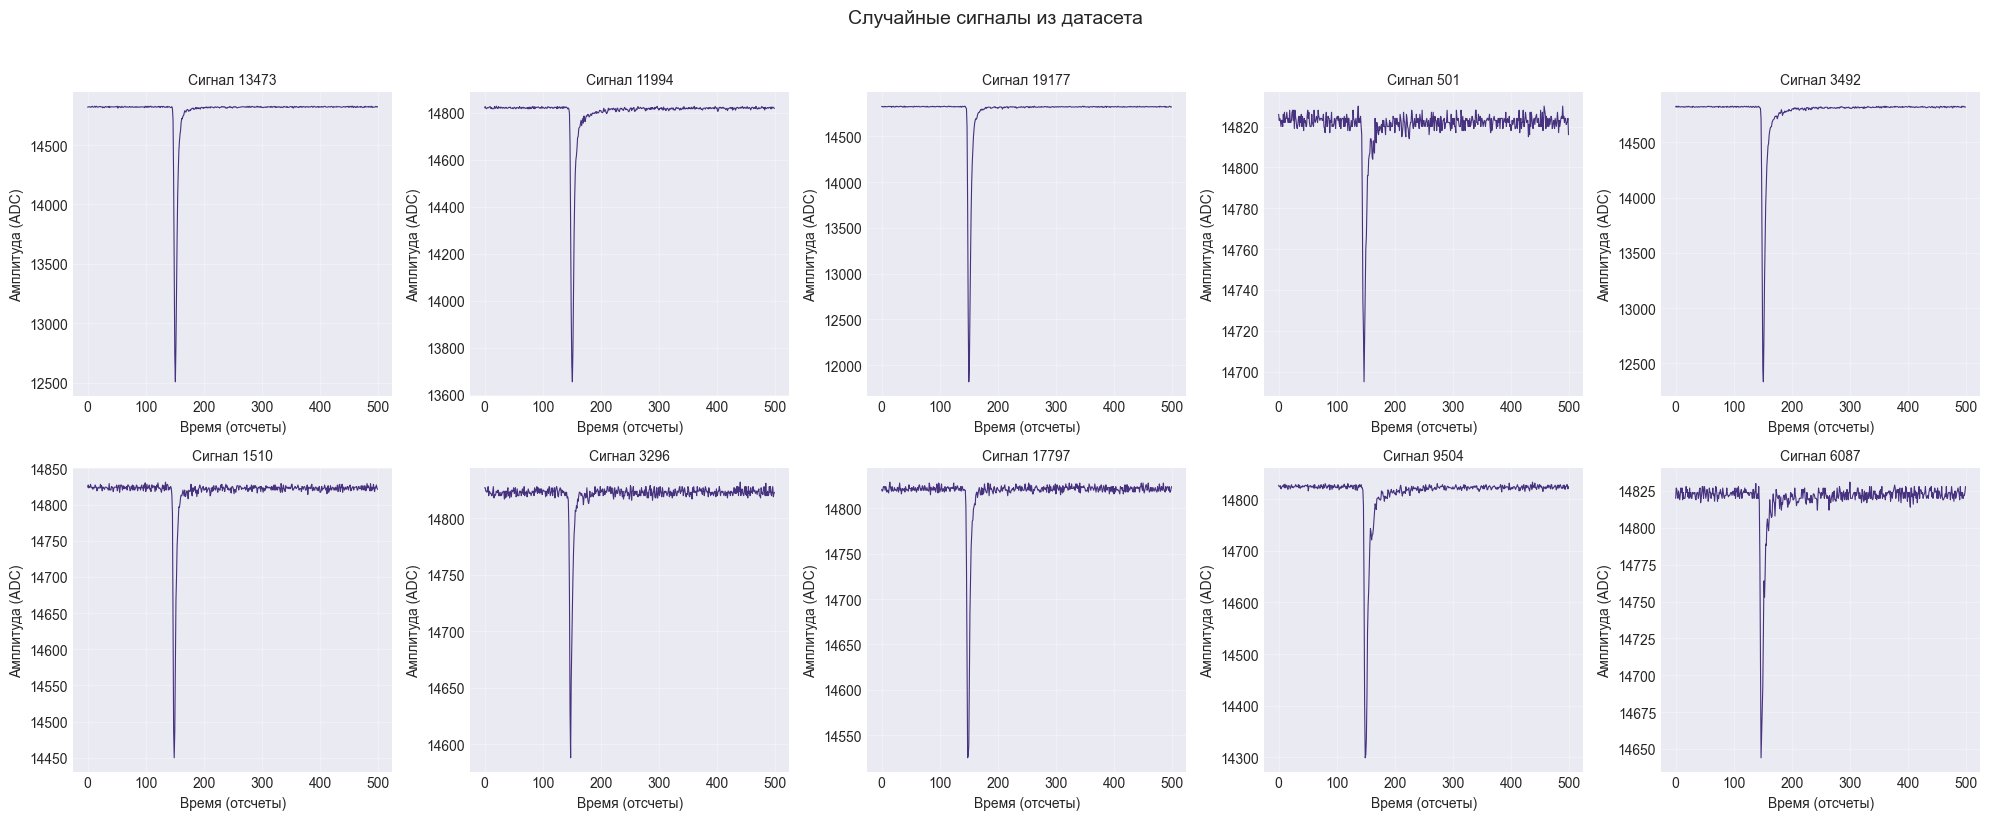

In [12]:
# Визуализация случайных сигналов

# Выбираем случайные индексы сигналов
np.random.seed(42)
random_indices = np.random.choice(dataset.shape[0], size=10, replace=False)
print(f"Случайно выбранные сигналы: {sorted(random_indices)}")

# Визуализация случайных сигналов
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    axes[i].plot(dataset.columns, dataset.iloc[idx], linewidth=0.8)
    axes[i].set_title(f'Сигнал {idx}', fontsize=10)
    axes[i].set_xlabel('Время (отсчеты)')
    axes[i].set_ylabel('Амплитуда (ADC)')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Случайные сигналы из датасета', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Средний сигнал и стандартное отклонение

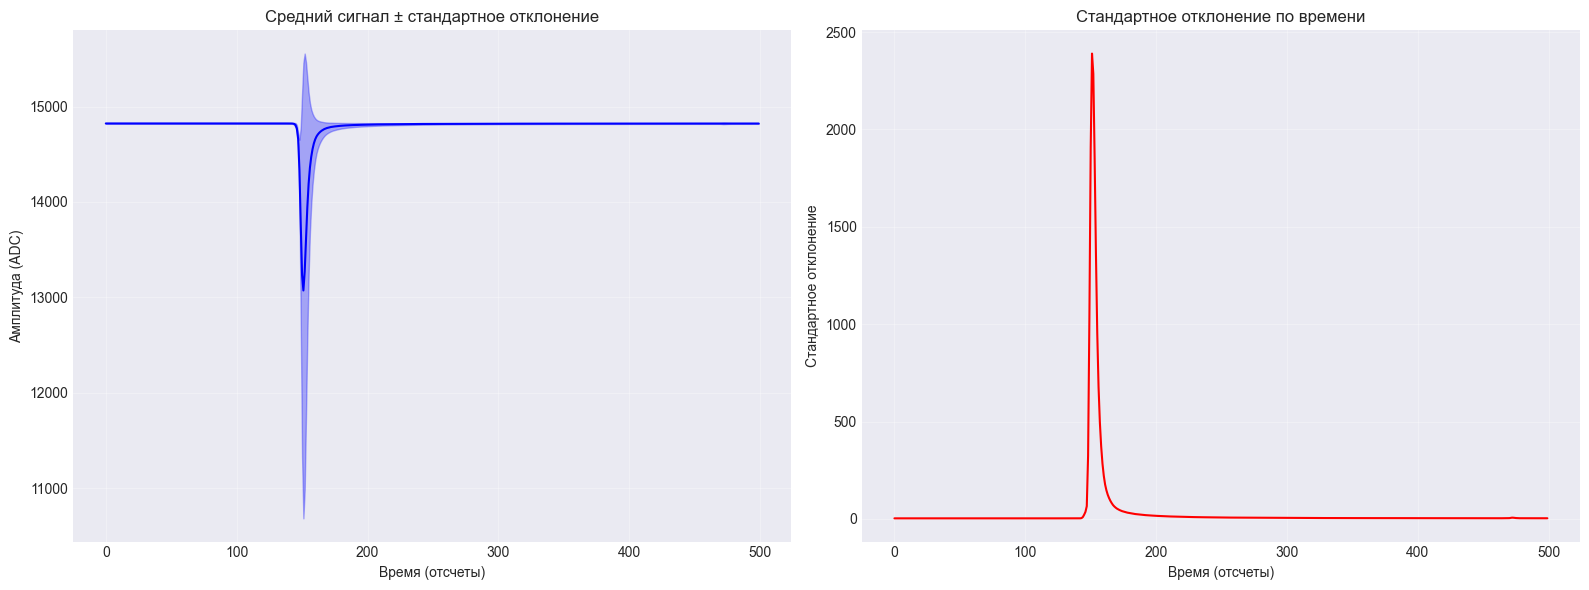

In [13]:
# Вычисляем средний сигнал и std по всем сигналам
mean_signal = dataset.mean(axis=0)
std_signal = dataset.std(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График среднего сигнала
ax1.plot(mean_signal, color='blue', linewidth=1.5)
ax1.fill_between(range(500), mean_signal - std_signal, mean_signal + std_signal,
                  alpha=0.3, color='blue')
ax1.set_title('Средний сигнал ± стандартное отклонение')
ax1.set_xlabel('Время (отсчеты)')
ax1.set_ylabel('Амплитуда (ADC)')
ax1.grid(True, alpha=0.3)

# График стандартного отклонения
ax2.plot(std_signal, color='red', linewidth=1.5)
ax2.set_title('Стандартное отклонение по времени')
ax2.set_xlabel('Время (отсчеты)')
ax2.set_ylabel('Стандартное отклонение')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print(f"Средняя амплитуда сигнала: {mean_signal.mean():.2f}")
print(f"Максимальное стандартное отклонение: {std_signal.max():.2f} на отсчете {std_signal.idxmax()}")

Средняя амплитуда сигнала: 14796.68
Максимальное стандартное отклонение: 2389.39 на отсчете 151


### Распределение амплитуд в ключевых точках

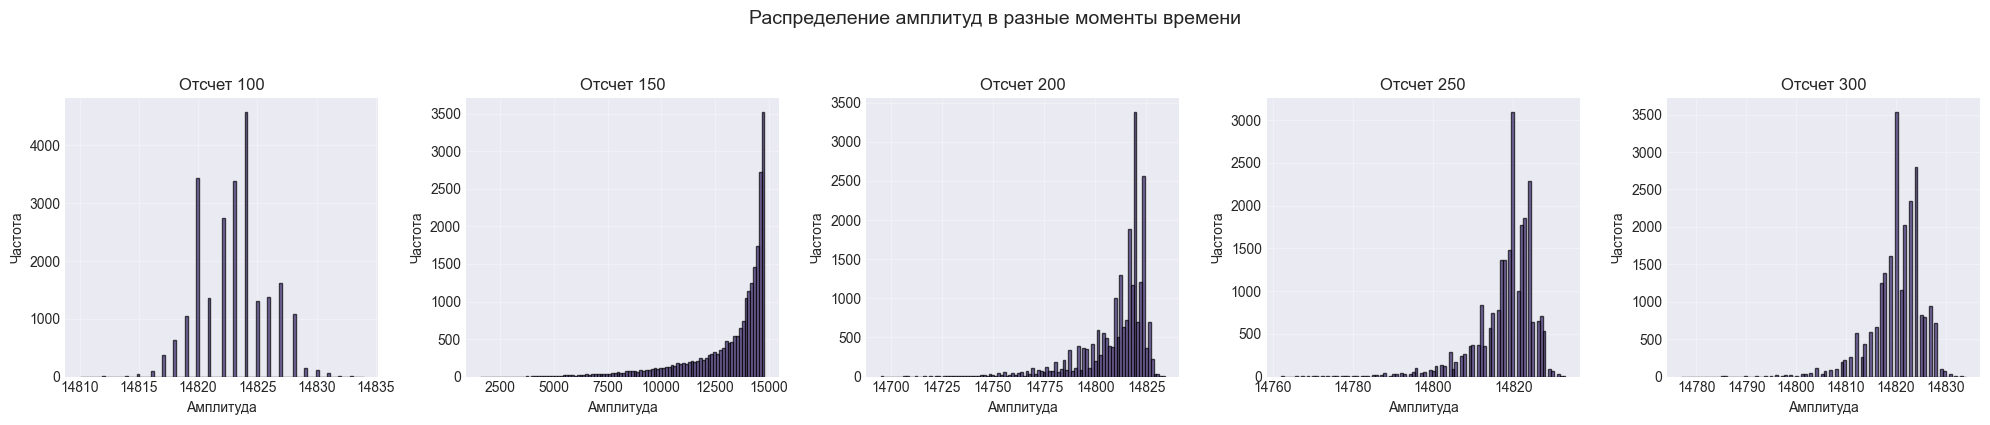

In [15]:
# Выбираем несколько ключевых временных точек для анализа
time_points = [100, 150, 200, 250, 300]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, tp in enumerate(time_points):
    axes[i].hist(dataset[tp], bins=100, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Отсчет {tp}')
    axes[i].set_xlabel('Амплитуда')
    axes[i].set_ylabel('Частота')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Распределение амплитуд в разные моменты времени', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### Тепловая карта всех сигналов

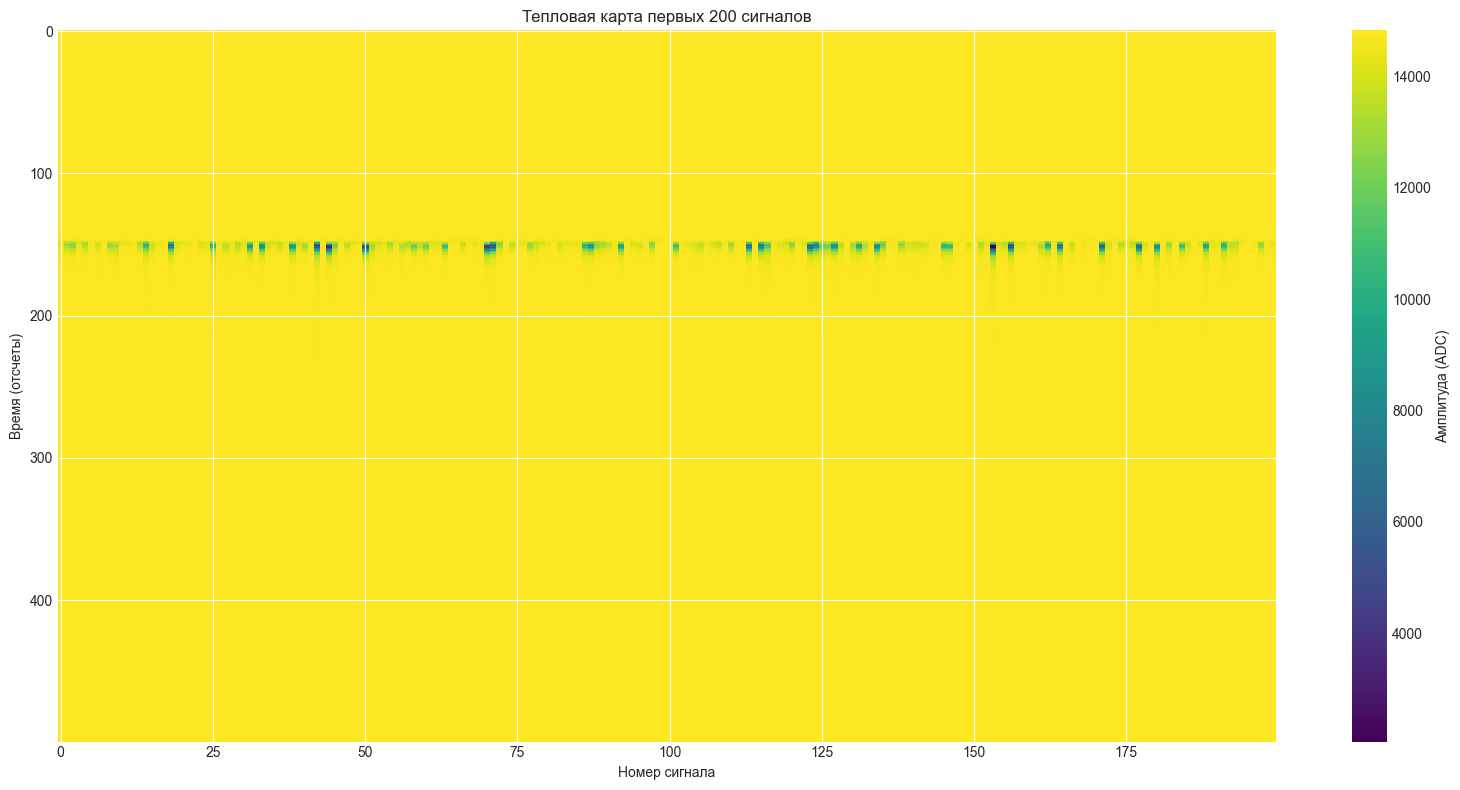

In [16]:
# Берем подвыборку для тепловой карты (первые 200 сигналов)
sample_size = min(200, dataset.shape[0])
sample_data = dataset.iloc[:sample_size]

plt.figure(figsize=(16, 8))
plt.imshow(sample_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(label='Амплитуда (ADC)')
plt.title(f'Тепловая карта первых {sample_size} сигналов')
plt.xlabel('Номер сигнала')
plt.ylabel('Время (отсчеты)')
plt.tight_layout()
plt.show()

### Анализ формы сигнала

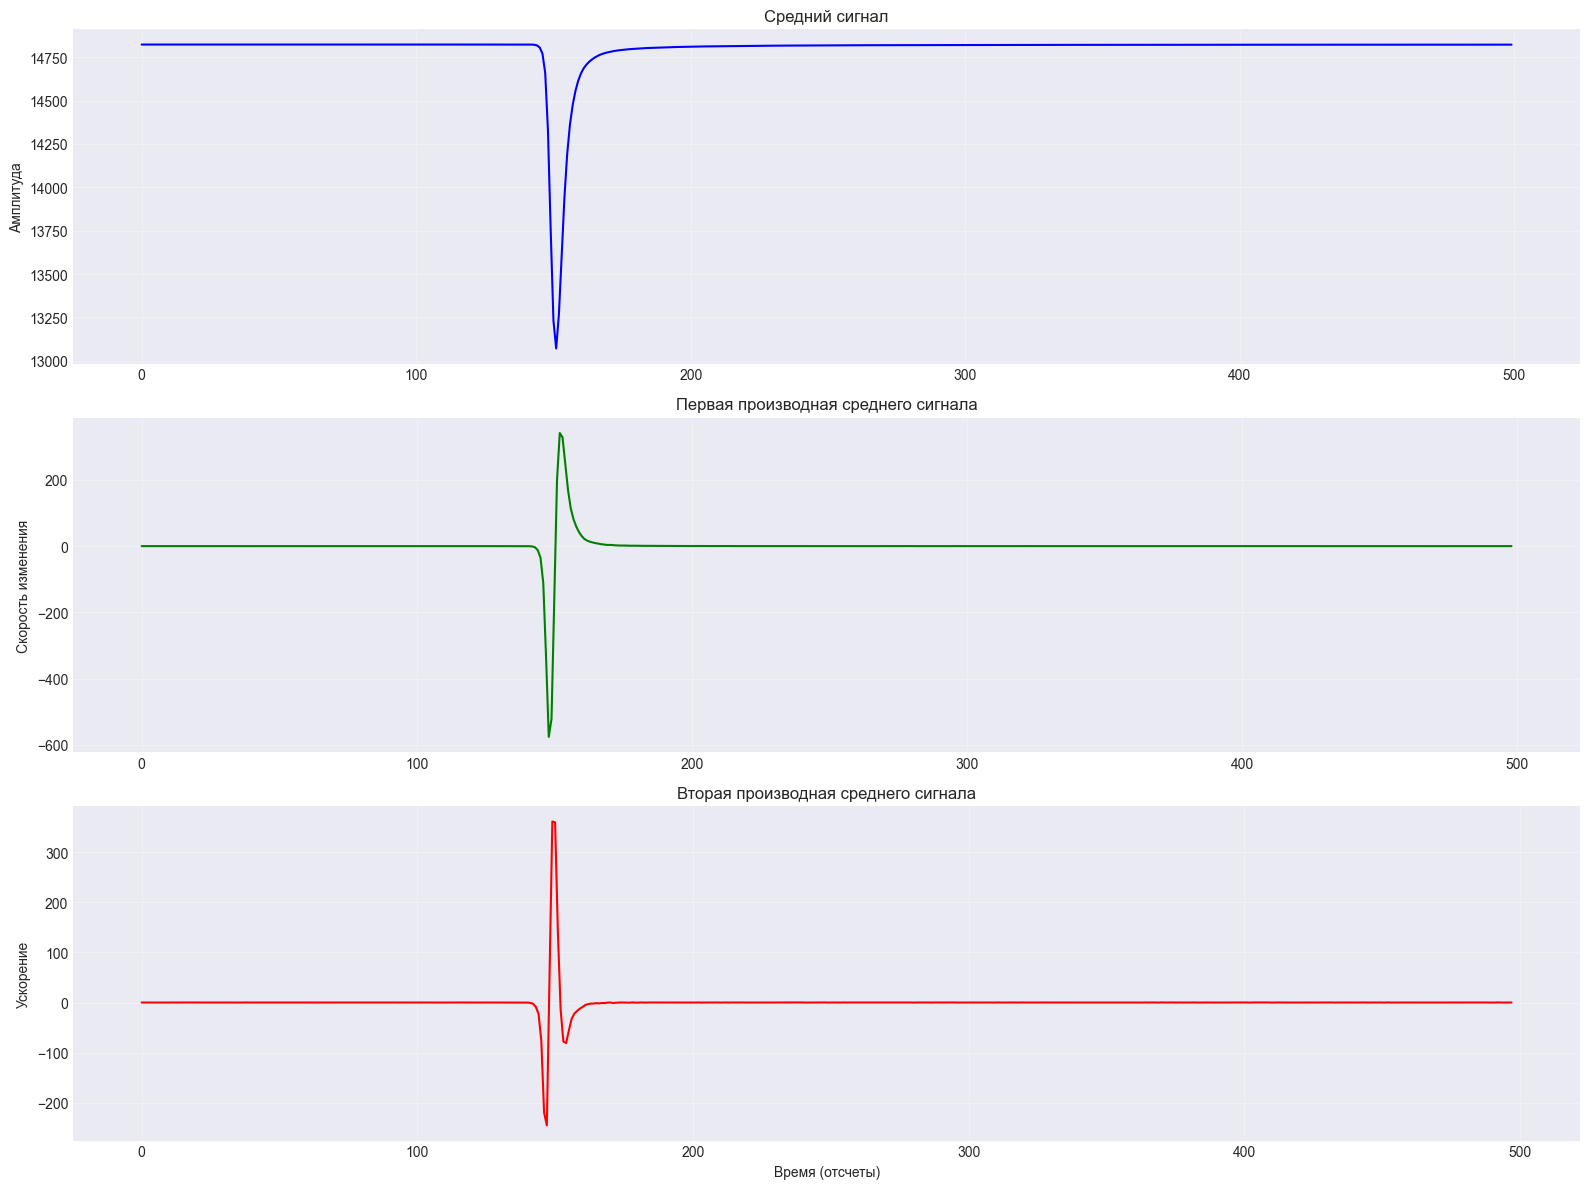

In [17]:
# Вычисляем первую производную для среднего сигнала
derivative = np.diff(mean_signal)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Средний сигнал
axes[0].plot(mean_signal, linewidth=1.5, color='blue')
axes[0].set_title('Средний сигнал')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True, alpha=0.3)

# Первая производная
axes[1].plot(derivative, linewidth=1.5, color='green')
axes[1].set_title('Первая производная среднего сигнала')
axes[1].set_ylabel('Скорость изменения')
axes[1].grid(True, alpha=0.3)

# Вторая производная
second_derivative = np.diff(derivative)
axes[2].plot(second_derivative, linewidth=1.5, color='red')
axes[2].set_title('Вторая производная среднего сигнала')
axes[2].set_xlabel('Время (отсчеты)')
axes[2].set_ylabel('Ускорение')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Поиск аномалий в данных

In [18]:
# Вычисляем интегральную амплитуду каждого сигнала
integral_amplitudes = dataset.sum(axis=1)

# Статистика по интегральным амплитудам
Q1 = integral_amplitudes.quantile(0.25)
Q3 = integral_amplitudes.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [19]:
print(f"Статистика интегральных амплитуд:")
print(f"  Среднее: {integral_amplitudes.mean():.2f}")
print(f"  Медиана: {integral_amplitudes.median():.2f}")
print(f"  Q1: {Q1:.2f}")
print(f"  Q3: {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Нижняя граница выбросов: {lower_bound:.2f}")
print(f"  Верхняя граница выбросов: {upper_bound:.2f}")

Статистика интегральных амплитуд:
  Среднее: 7398341.86
  Медиана: 7405248.00
  Q1: 7394148.50
  Q3: 7409017.00
  IQR: 14868.50
  Нижняя граница выбросов: 7371845.75
  Верхняя граница выбросов: 7431319.75


In [20]:
# Находим потенциальные выбросы
outliers = integral_amplitudes[(integral_amplitudes < lower_bound) |
                                (integral_amplitudes > upper_bound)]
print(f"Количество потенциальных выбросов: {len(outliers)}")
print(f"Индексы выбросов: {outliers.index.tolist()[:10]}...")

Количество потенциальных выбросов: 1862
Индексы выбросов: [18, 33, 42, 44, 50, 70, 71, 87, 113, 115]...


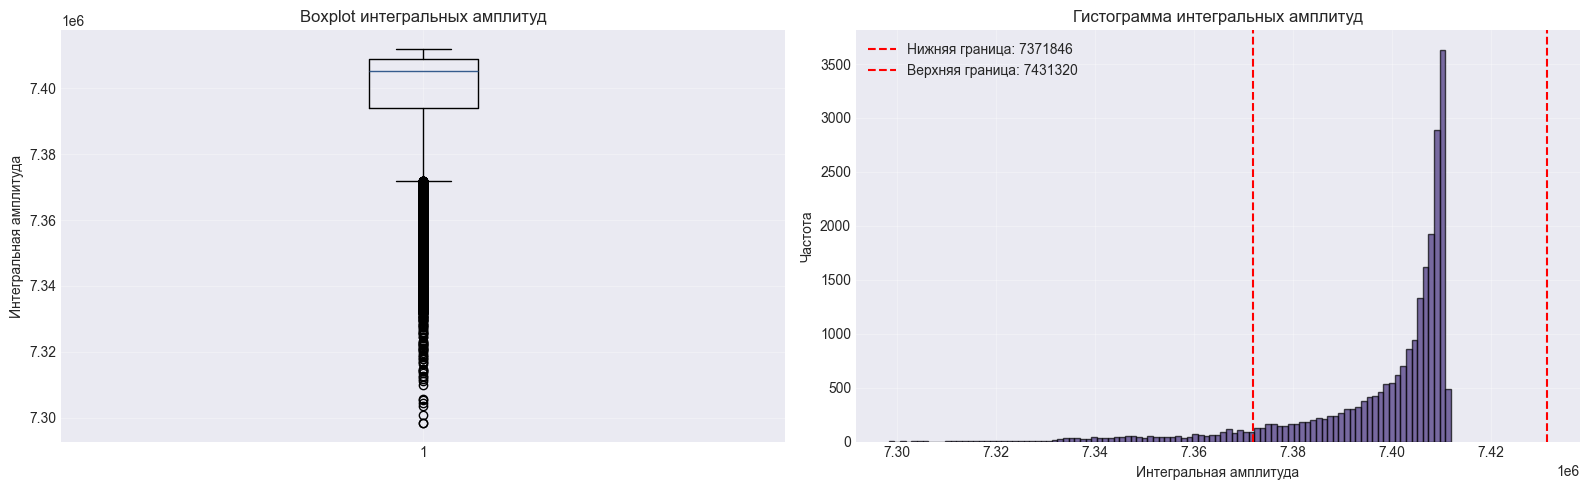

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
ax1.boxplot(integral_amplitudes)
ax1.set_title('Boxplot интегральных амплитуд')
ax1.set_ylabel('Интегральная амплитуда')
ax1.grid(True, alpha=0.3)

# Гистограмма
ax2.hist(integral_amplitudes, bins=100, edgecolor='black', alpha=0.7)
ax2.axvline(lower_bound, color='red', linestyle='--', label=f'Нижняя граница: {lower_bound:.0f}')
ax2.axvline(upper_bound, color='red', linestyle='--', label=f'Верхняя граница: {upper_bound:.0f}')
ax2.set_title('Гистограмма интегральных амплитуд')
ax2.set_xlabel('Интегральная амплитуда')
ax2.set_ylabel('Частота')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

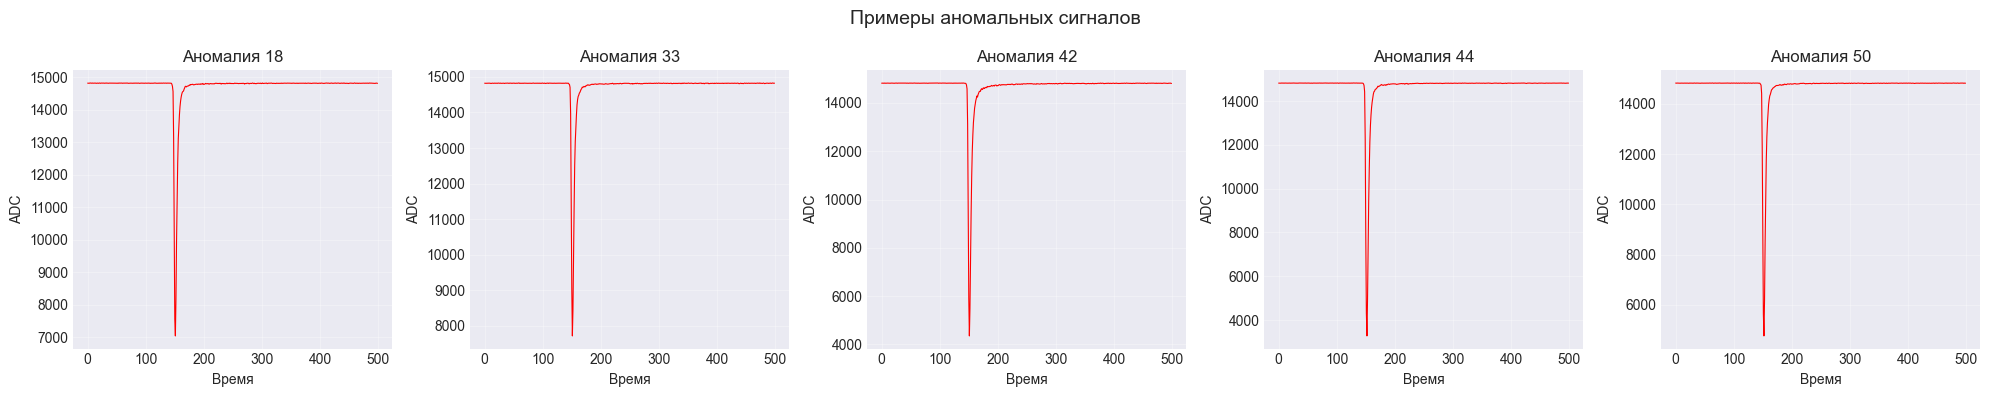

In [22]:
if len(outliers) >= 5:
    outlier_indices = outliers.index[:5]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for i, idx in enumerate(outlier_indices):
        axes[i].plot(dataset.columns, dataset.iloc[idx], linewidth=0.8, color='red')
        axes[i].set_title(f'Аномалия {idx}')
        axes[i].set_xlabel('Время')
        axes[i].set_ylabel('ADC')
        axes[i].grid(True, alpha=0.3)
    plt.suptitle('Примеры аномальных сигналов', fontsize=14)
    plt.tight_layout()
    plt.show()

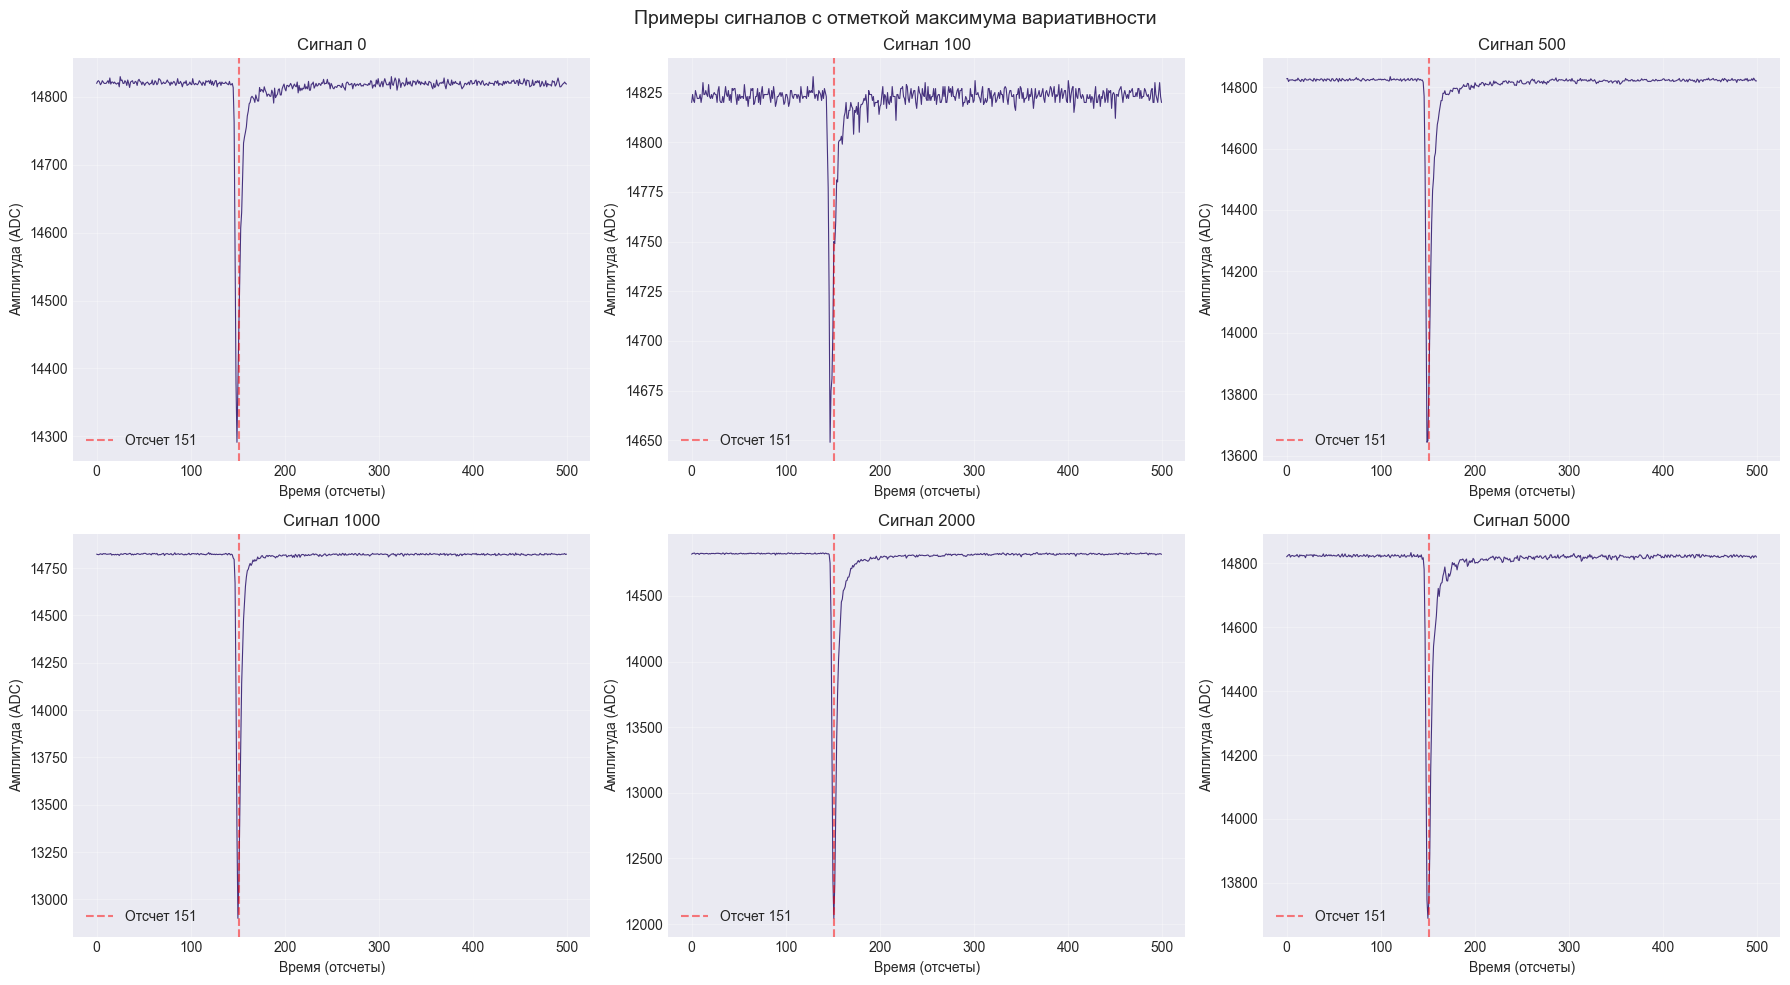

In [23]:
# Визуализируем несколько сигналов с акцентом на область импульса
indices_to_plot = [0, 100, 500, 1000, 2000, 5000]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, idx in enumerate(indices_to_plot):
    axes[i].plot(dataset.iloc[idx].values, linewidth=0.8)
    axes[i].axvline(x=151, color='red', linestyle='--', alpha=0.5, label='Отсчет 151')
    axes[i].set_title(f'Сигнал {idx}')
    axes[i].set_xlabel('Время (отсчеты)')
    axes[i].set_ylabel('Амплитуда (ADC)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Примеры сигналов с отметкой максимума вариативности', fontsize=14)
plt.tight_layout()
plt.show()

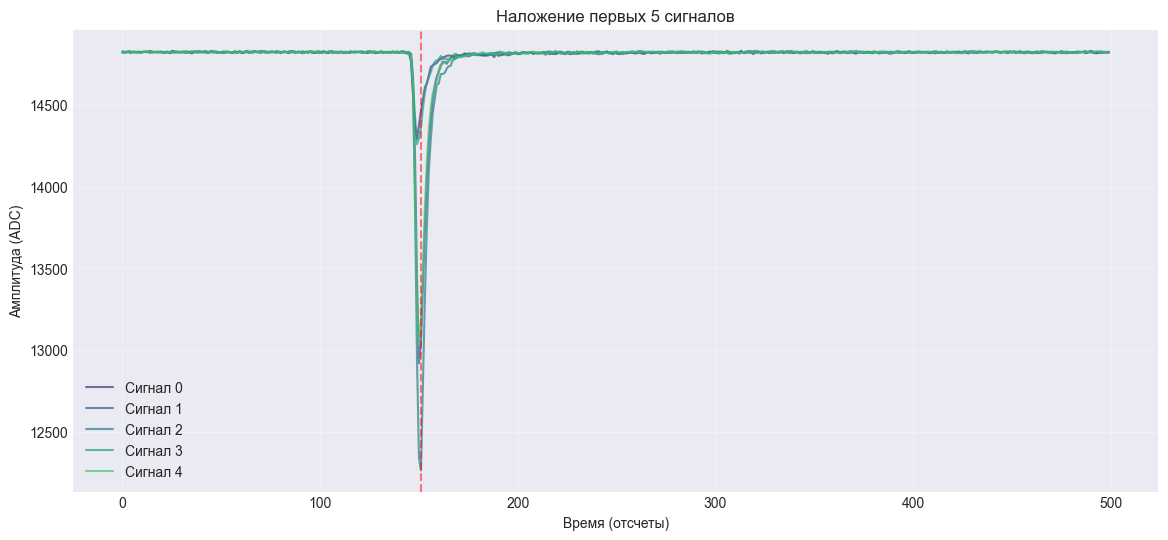

In [24]:
# Сравним первые 5 сигналов на одном графике
plt.figure(figsize=(14, 6))
for i in range(5):
    plt.plot(dataset.iloc[i].values, label=f'Сигнал {i}', alpha=0.7)
plt.axvline(x=151, color='red', linestyle='--', alpha=0.5)
plt.title('Наложение первых 5 сигналов')
plt.xlabel('Время (отсчеты)')
plt.ylabel('Амплитуда (ADC)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Feature Engineering и предобработка данных

### Извлечение признаков из одного сигнала

In [25]:
from scipy import stats

def extract_features(waveform, baseline_region=50):
    """
    Извлечение признаков из одного сигнала.

    Параметры:
    waveform : array-like (500,)
    baseline_region : int, количество отсчетов для оценки базовой линии

    Возвращает:
    dict с признаками
    """
    # Оцениваем базовую линию (первые отсчеты до импульса)
    baseline = np.mean(waveform[:baseline_region])

    # Вычитаем базовую линию для анализа формы импульса
    waveform_bs = waveform - baseline

    # Ищем минимум (отрицательный импульс) или максимум
    # В сцинтилляторах импульс обычно положительный, но проверим оба варианта
    min_val = np.min(waveform_bs)
    max_val = np.max(waveform_bs)

    if abs(min_val) > abs(max_val):
        amplitude = abs(min_val)
        pulse_polarity = -1
        pulse_idx = np.argmin(waveform_bs)
    else:
        amplitude = max_val
        pulse_polarity = 1
        pulse_idx = np.argmax(waveform_bs)

    # Площадь под кривой (интеграл)
    area = np.sum(np.abs(waveform_bs))

    # Время нарастания (от 10% до 90% амплитуды)
    threshold_10 = 0.1 * amplitude
    threshold_90 = 0.9 * amplitude

    # Ищем индексы для времени нарастания
    above_10 = np.where(waveform_bs * pulse_polarity >= threshold_10)[0]
    above_90 = np.where(waveform_bs * pulse_polarity >= threshold_90)[0]

    if len(above_10) > 0 and len(above_90) > 0:
        rise_start = above_10[0]
        rise_end = above_90[0]
        rise_time = rise_end - rise_start
    else:
        rise_time = 0

    # Время спада (от 90% до 10% после пика)
    after_peak = waveform_bs[pulse_idx:] * pulse_polarity
    below_90_after = np.where(after_peak <= threshold_90)[0]
    below_10_after = np.where(after_peak <= threshold_10)[0]

    if len(below_90_after) > 0 and len(below_10_after) > 0:
        fall_start = below_90_after[0] + pulse_idx
        fall_end = below_10_after[0] + pulse_idx
        fall_time = fall_end - fall_start
    else:
        fall_time = 0

    # Ширина импульса на половине высоты (FWHM)
    half_max = 0.5 * amplitude
    above_half = np.where(waveform_bs * pulse_polarity >= half_max)[0]

    if len(above_half) >= 2:
        fwhm = above_half[-1] - above_half[0]
    else:
        fwhm = 0

    # Статистические моменты
    skewness = stats.skew(waveform_bs)
    kurtosis = stats.kurtosis(waveform_bs)

    # Отношение площади до пика к площади после пика
    area_before_peak = np.sum(np.abs(waveform_bs[:pulse_idx]))
    area_after_peak = np.sum(np.abs(waveform_bs[pulse_idx:]))
    area_ratio = area_before_peak / (area_after_peak + 1)  # +1 чтобы избежать деления на 0

    # Среднеквадратичное отклонение
    rms = np.sqrt(np.mean(waveform_bs**2))

    features = {
        'amplitude': amplitude,
        'baseline': baseline,
        'area': area,
        'pulse_position': pulse_idx,
        'rise_time': rise_time,
        'fall_time': fall_time,
        'fwhm': fwhm,
        'skewness': skewness,
        'kurtosis': kurtosis,
        'area_ratio': area_ratio,
        'rms': rms
    }

    return features

In [26]:
all_features = []
for i in range(dataset.shape[0]):
    features = extract_features(dataset.iloc[i].values)
    all_features.append(features)

    if (i + 1) % 5000 == 0:
        print(f"  Обработано {i + 1} сигналов...")
features_df = pd.DataFrame(all_features)

  Обработано 5000 сигналов...
  Обработано 10000 сигналов...
  Обработано 15000 сигналов...
  Обработано 20000 сигналов...


In [27]:
print(f"Извлечено {len(features_df)} сигналов × {features_df.shape[1]} признаков")

Извлечено 23479 сигналов × 11 признаков


In [28]:
features_df.head()

,amplitude,baseline,area,pulse_position,rise_time,fall_time,fwhm,skewness,kurtosis,area_ratio,rms
0,530.48,14821.48,5426.76,149,3,10,4,-8.208985,73.233273,0.253003,47.145418
1,1901.48,14822.48,12965.40,150,2,7,4,-8.936672,84.934025,0.240267,164.969250
2,2557.90,14821.90,17570.40,151,3,7,4,-8.869747,83.454824,0.507925,227.680719
3,564.56,14822.56,5350.08,149,2,8,4,-8.412439,76.386935,0.220482,50.893500
4,1793.60,14821.60,12444.20,150,3,7,4,-8.862719,83.048625,0.301908,158.127077


In [29]:
features_df.describe().round(2)

,amplitude,baseline,area,pulse_position,rise_time,fall_time,fwhm,skewness,kurtosis,area_ratio,rms
count,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00
mean,1835.10,14822.97,13893.93,149.63,2.47,8.68,4.24,-8.42,77.00,0.32,163.69
std,2389.30,0.86,15956.40,2.49,2.17,2.13,2.22,0.59,9.73,0.08,211.21
min,104.30,14818.92,1670.20,145.00,1.00,3.00,2.00,-12.08,41.39,0.12,10.35
25%,308.16,14822.38,3333.24,149.00,2.00,7.00,4.00,-8.95,70.04,0.25,28.13
50%,812.54,14822.96,7005.60,150.00,2.00,8.00,4.00,-8.48,77.59,0.31,73.17
75%,2315.05,14823.54,17913.64,151.00,3.00,10.00,5.00,-8.02,85.21,0.37,207.57
max,14824.84,14826.48,113491.16,472.00,325.00,21.00,326.00,-6.11,161.93,1.28,1500.57


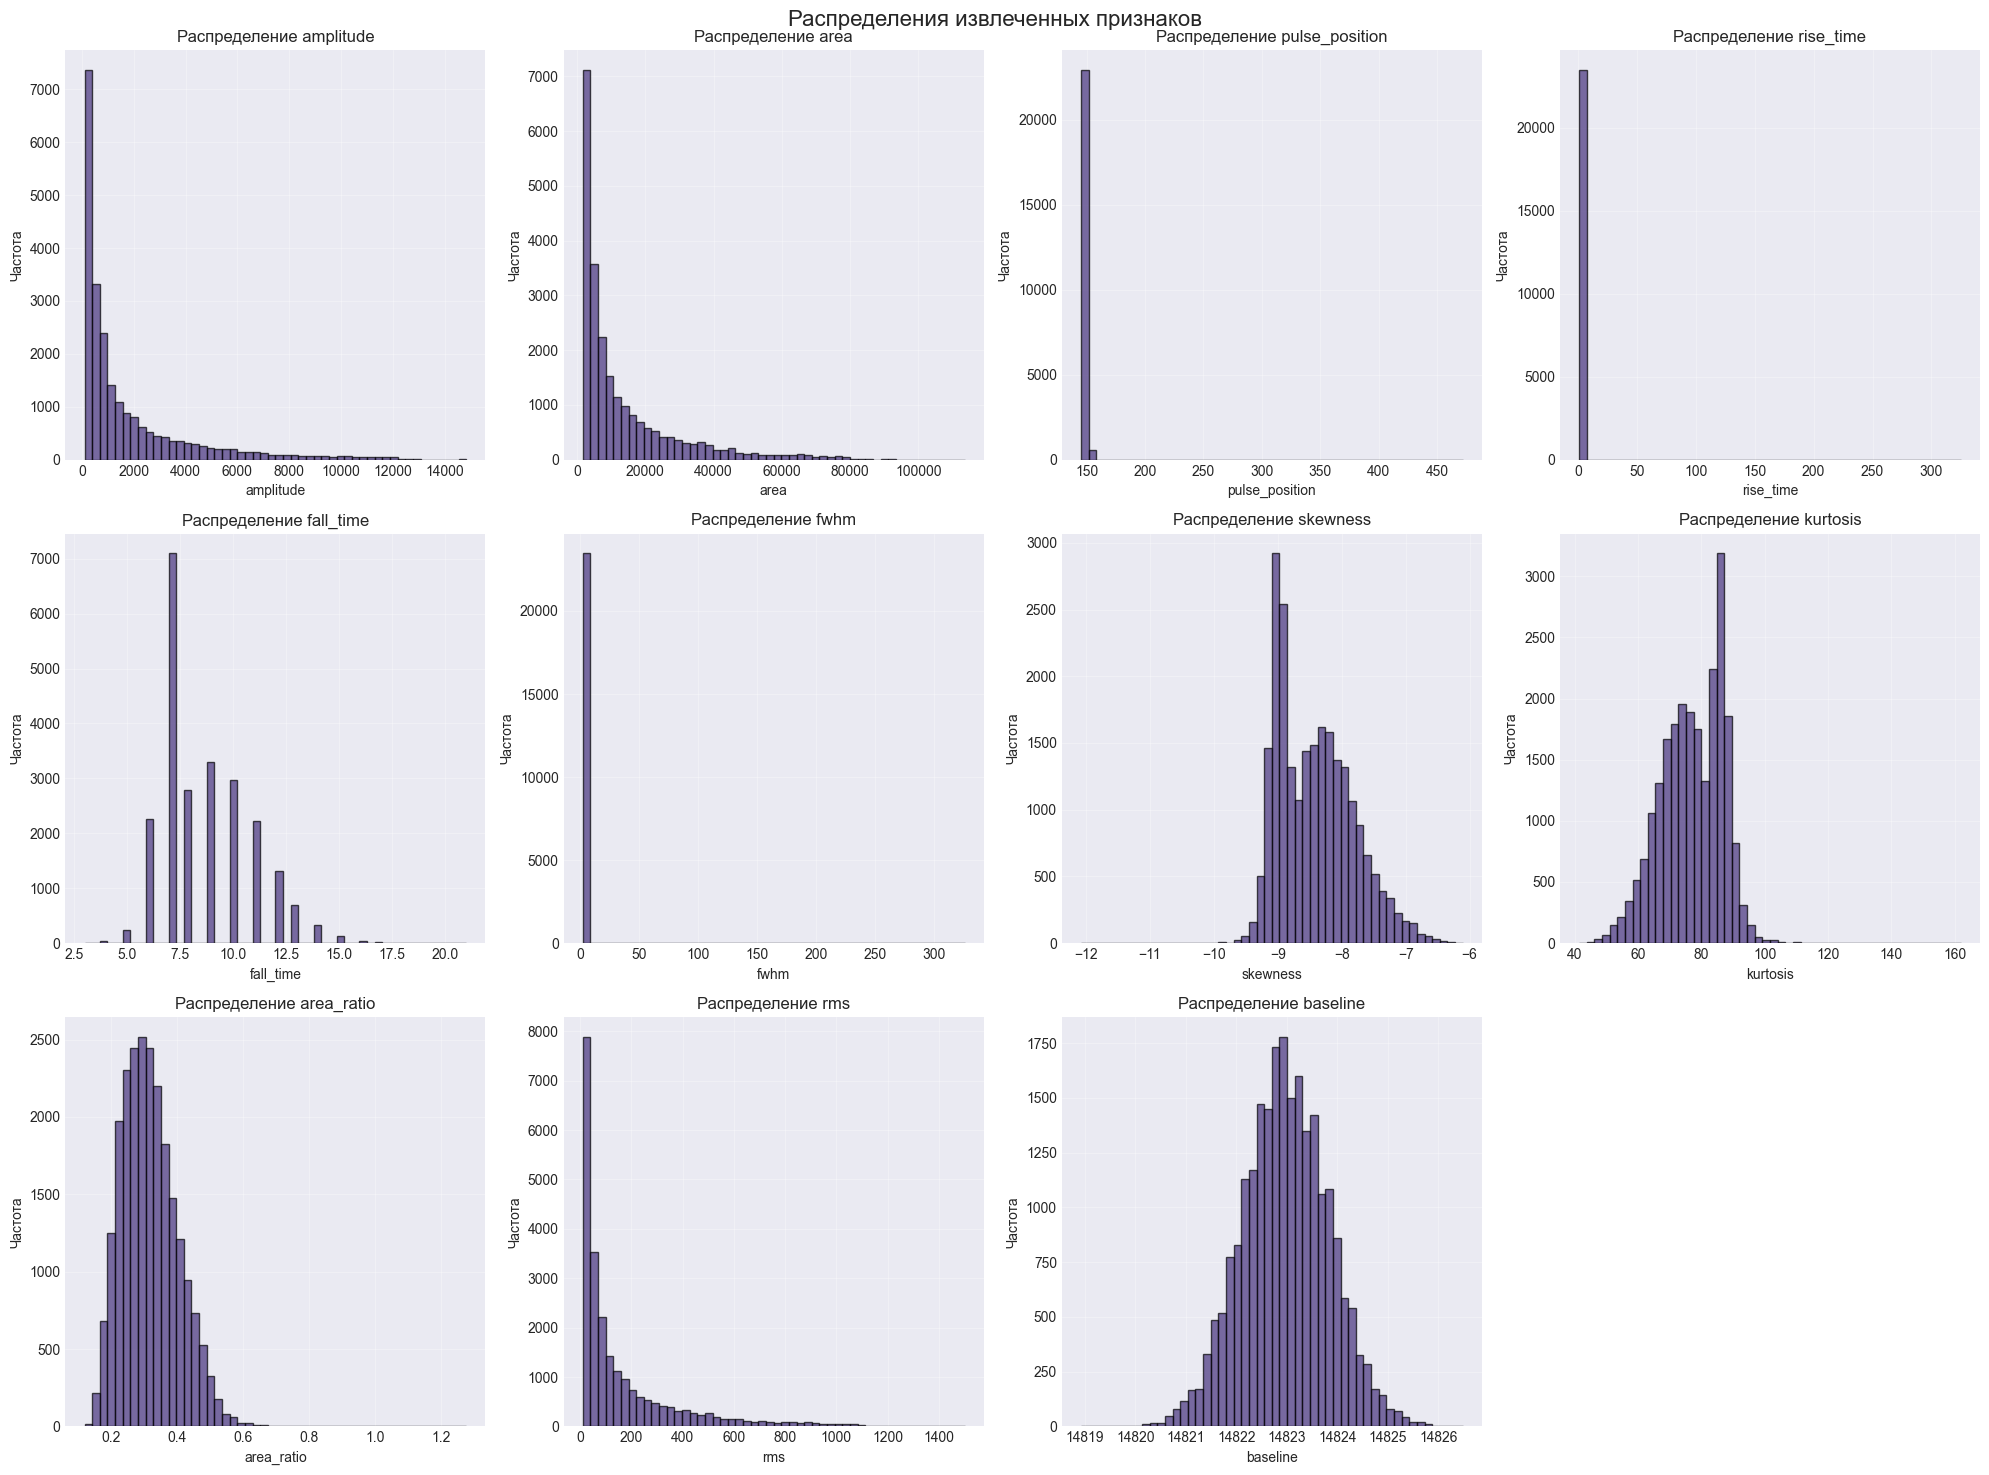

In [30]:
# Визуализация распределений признаков
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

features_to_plot = ['amplitude', 'area', 'pulse_position', 'rise_time',
                    'fall_time', 'fwhm', 'skewness', 'kurtosis',
                    'area_ratio', 'rms', 'baseline']

for i, feature in enumerate(features_to_plot):
    if i < len(axes):
        axes[i].hist(features_df[feature], bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Распределение {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Частота')
        axes[i].grid(True, alpha=0.3)

# Убираем лишнюю пустую ось
if len(features_to_plot) < len(axes):
    axes[-1].axis('off')

plt.suptitle('Распределения извлеченных признаков', fontsize=16)
plt.tight_layout()
plt.show()

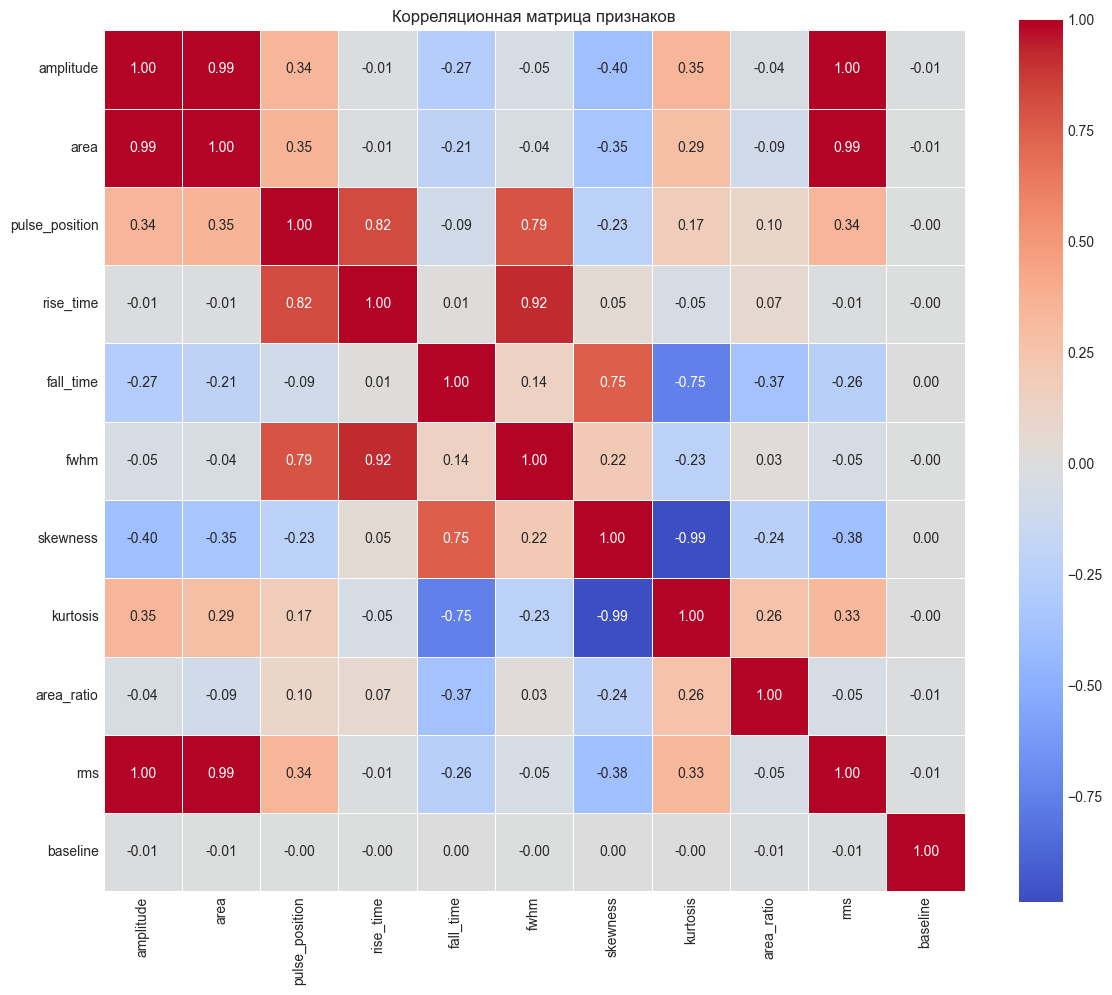

In [31]:
# Корреляционная матрица признаков
plt.figure(figsize=(12, 10))
correlation_matrix = features_df[features_to_plot].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

### Предобработка данных

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [33]:
# Выбираем признаки, удаляя избыточные
# Удаляем: baseline (нет связи), rms (дублирует amplitude)
# Оставляем один из пары skewness/kurtosis — оставим skewness
selected_features = ['amplitude', 'area', 'pulse_position', 'rise_time',
                     'fall_time', 'fwhm', 'skewness', 'area_ratio']

In [34]:
X = features_df[selected_features].copy()

In [35]:
print(f"Выбрано признаков: {len(selected_features)}")
print(f"Признаки: {selected_features}")
print(f"Форма матрицы признаков: {X.shape}")

Выбрано признаков: 8
Признаки: ['amplitude', 'area', 'pulse_position', 'rise_time', 'fall_time', 'fwhm', 'skewness', 'area_ratio']
Форма матрицы признаков: (23479, 8)


In [36]:
# Проверка на пропуски и бесконечности
print(f"Пропущенных значений: {X.isnull().sum().sum()}")
print(f"Бесконечных значений: {np.isinf(X.values).sum()}")


Пропущенных значений: 0
Бесконечных значений: 0


In [37]:
# Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

In [38]:
X_scaled_df.describe().round(2)

,amplitude,area,pulse_position,rise_time,fall_time,fwhm,skewness,area_ratio
count,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00
mean,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.72,-0.77,-1.86,-0.67,-2.66,-1.01,-6.19,-2.34
25%,-0.64,-0.66,-0.25,-0.22,-0.78,-0.11,-0.89,-0.75
50%,-0.43,-0.43,0.15,-0.22,-0.32,-0.11,-0.09,-0.11
75%,0.20,0.25,0.55,0.24,0.62,0.34,0.69,0.64
max,5.44,6.24,129.47,148.31,5.78,145.26,3.92,11.42


In [39]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [40]:
print(f"Объясненная дисперсия PCA:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"  Сумма: {pca.explained_variance_ratio_.sum():.3f}")

Объясненная дисперсия PCA:
  PC1: 0.354
  PC2: 0.316
  Сумма: 0.670


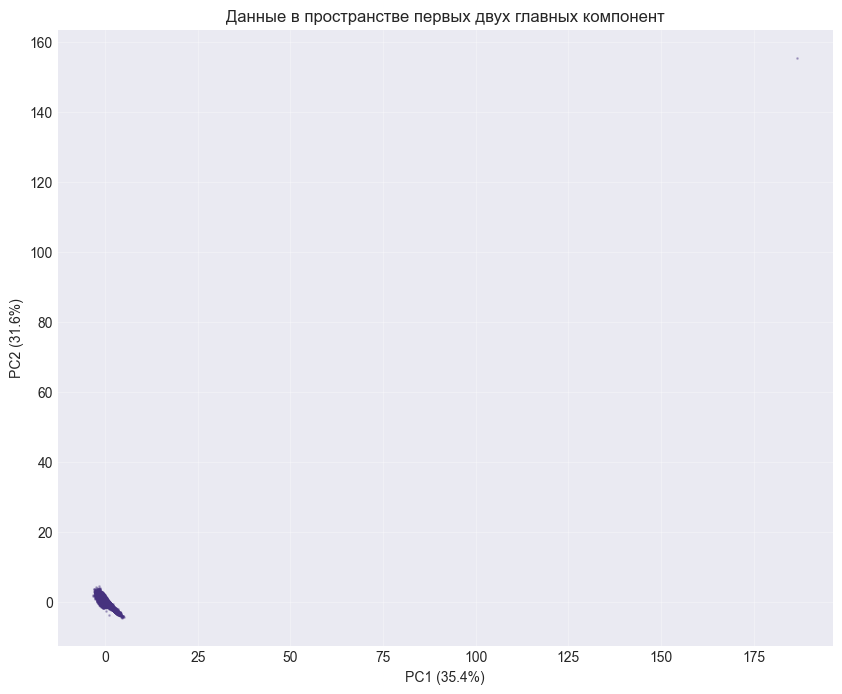

In [41]:
# Визуализация в пространстве первых двух компонент
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=1)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Данные в пространстве первых двух главных компонент')
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
# Загрузки признаков на главные компоненты
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=selected_features
)
print("\nВклад признаков в главные компоненты:")
print(loadings.round(3))


Вклад признаков в главные компоненты:
                  PC1    PC2
amplitude       0.369 -0.368
area            0.362 -0.347
pulse_position  0.537  0.209
rise_time       0.419  0.410
fall_time      -0.219  0.368
fwhm            0.376  0.466
skewness       -0.262  0.415
area_ratio      0.105 -0.081


## Кластеризация

In [43]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Функция для оценки качества кластеризации
def evaluate_clustering(X, labels, method_name):
    """Оценка качества кластеризации"""
    # Исключаем шумовые точки (label=-1) для DBSCAN
    mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"\n{method_name}:")
    print(f"  Количество кластеров: {n_clusters}")
    print(f"  Количество шумовых точек: {n_noise}")
    print(f"  Распределение по кластерам:")
    for label in sorted(set(labels)):
        count = list(labels).count(label)
        if label == -1:
            print(f"    Шум: {count} ({count/len(labels)*100:.1f}%)")
        else:
            print(f"    Кластер {label}: {count} ({count/len(labels)*100:.1f}%)")

    if n_clusters >= 2 and mask.sum() > 0:
        silhouette = silhouette_score(X[mask], labels[mask])
        davies_bouldin = davies_bouldin_score(X[mask], labels[mask])
        print(f"  Silhouette Score: {silhouette:.3f}")
        print(f"  Davies-Bouldin Index: {davies_bouldin:.3f}")

    return labels

### K-Means

In [44]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_labels = evaluate_clustering(X_scaled, kmeans_labels, "K-Means")


K-Means:
  Количество кластеров: 3
  Количество шумовых точек: 0
  Распределение по кластерам:
    Кластер 0: 12937 (55.1%)
    Кластер 1: 10541 (44.9%)
    Кластер 2: 1 (0.0%)
  Silhouette Score: 0.298
  Davies-Bouldin Index: 0.872


In [45]:
print("Центры кластеров (в исходном масштабе):")
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
for i, center in enumerate(centers_original):
    print(f"  Кластер {i}:", dict(zip(selected_features, center.round(2))))

Центры кластеров (в исходном масштабе):
  Кластер 0: {'amplitude': np.float64(2740.08), 'area': np.float64(19364.75), 'pulse_position': np.float64(150.04), 'rise_time': np.float64(2.4), 'fall_time': np.float64(7.23), 'fwhm': np.float64(3.93), 'skewness': np.float64(-8.85), 'area_ratio': np.float64(0.34)}
  Кластер 1: {'amplitude': np.float64(725.86), 'area': np.float64(7188.17), 'pulse_position': np.float64(149.09), 'rise_time': np.float64(2.52), 'fall_time': np.float64(10.45), 'fwhm': np.float64(4.6), 'skewness': np.float64(-7.89), 'area_ratio': np.float64(0.28)}
  Кластер 2: {'amplitude': np.float64(819.5), 'area': np.float64(8530.0), 'pulse_position': np.float64(472.0), 'rise_time': np.float64(325.0), 'fall_time': np.float64(6.0), 'fwhm': np.float64(326.0), 'skewness': np.float64(-7.02), 'area_ratio': np.float64(1.28)}


### DBSCAN

In [46]:
# Подбираем параметры: eps определяет радиус окрестности
dbscan = DBSCAN(eps=0.8, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_labels = evaluate_clustering(X_scaled, dbscan_labels, "DBSCAN (eps=0.8)")


DBSCAN (eps=0.8):
  Количество кластеров: 1
  Количество шумовых точек: 88
  Распределение по кластерам:
    Шум: 88 (0.4%)
    Кластер 0: 23391 (99.6%)


In [47]:
# Если DBSCAN нашел только 1 кластер или слишком много шума,
# попробуем другие параметры
if len(set(dbscan_labels)) <= 2:
    print("Пробуем другие параметры DBSCAN...")
    for eps_val in [1.0, 1.5, 2.0]:
        dbscan_tmp = DBSCAN(eps=eps_val, min_samples=10)
        labels_tmp = dbscan_tmp.fit_predict(X_scaled)
        n_clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
        n_noise = list(labels_tmp).count(-1)
        print(f"  eps={eps_val}: кластеров={n_clusters}, шума={n_noise}")


  Пробуем другие параметры DBSCAN...
  eps=1.0: кластеров=1, шума=31
  eps=1.5: кластеров=1, шума=3
  eps=2.0: кластеров=1, шума=2


### Gaussian Mixture Model

In [48]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_labels = evaluate_clustering(X_scaled, gmm_labels, "GMM")


GMM:
  Количество кластеров: 3
  Количество шумовых точек: 0
  Распределение по кластерам:
    Кластер 0: 12126 (51.6%)
    Кластер 1: 11352 (48.3%)
    Кластер 2: 1 (0.0%)
  Silhouette Score: 0.206
  Davies-Bouldin Index: 1.100


### Сравнение всех методов

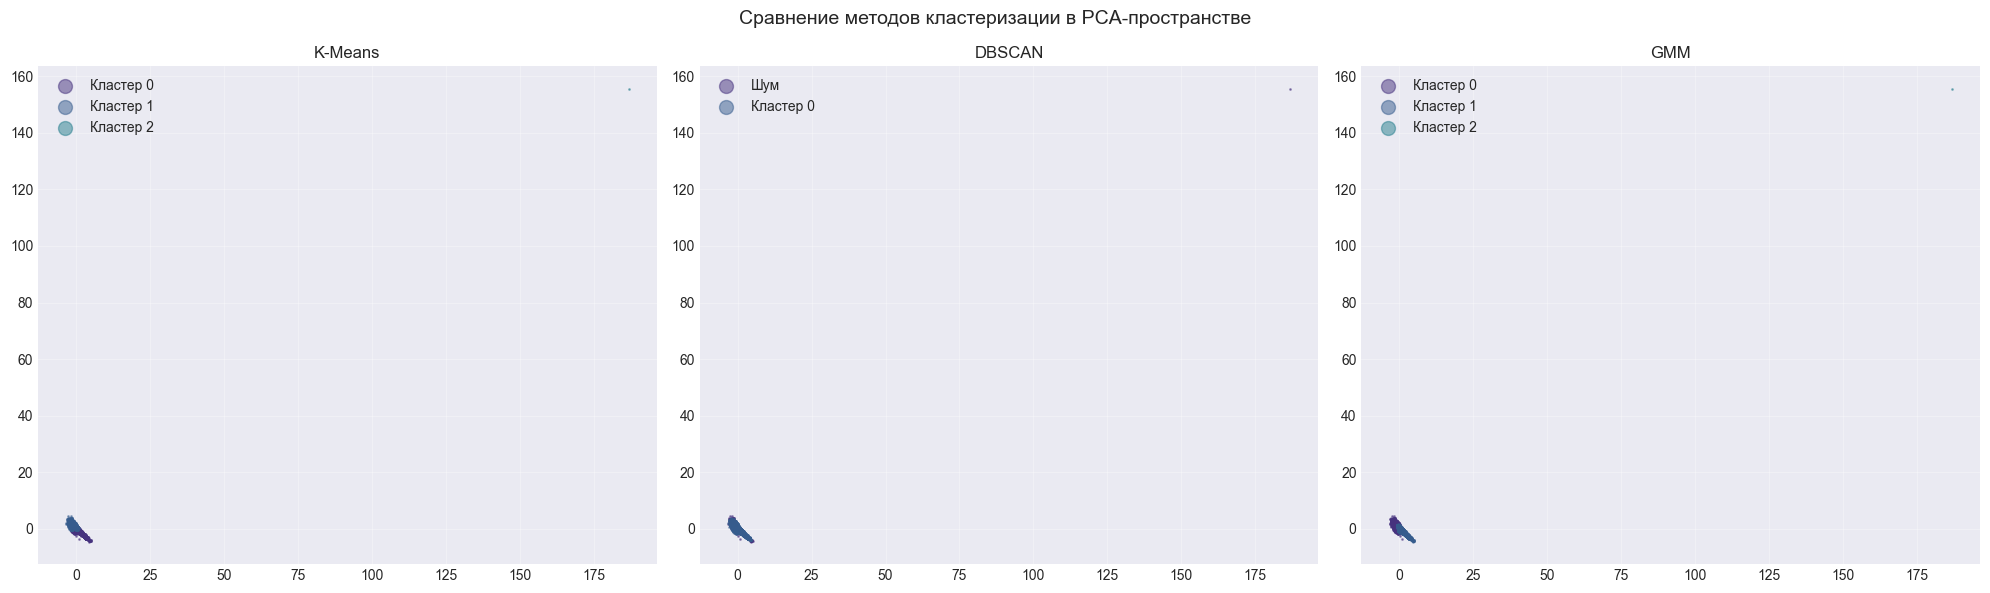

In [49]:
# Визуализация всех методов
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Цвета для кластеров
colors_kmeans = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors_dbscan = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # +красный для шума
colors_gmm = ['#1f77b4', '#ff7f0e', '#2ca02c']

# K-Means
for label in sorted(set(kmeans_labels)):
    mask = kmeans_labels == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=1, alpha=0.5, label=f'Кластер {label}')
axes[0].set_title('K-Means')
axes[0].legend(markerscale=10)
axes[0].grid(True, alpha=0.3)

# DBSCAN
for label in sorted(set(dbscan_labels)):
    mask = dbscan_labels == label
    label_name = 'Шум' if label == -1 else f'Кластер {label}'
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=1, alpha=0.5, label=label_name)
axes[1].set_title('DBSCAN')
axes[1].legend(markerscale=10)
axes[1].grid(True, alpha=0.3)

# GMM
for label in sorted(set(gmm_labels)):
    mask = gmm_labels == label
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=1, alpha=0.5, label=f'Кластер {label}')
axes[2].set_title('GMM')
axes[2].legend(markerscale=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Сравнение методов кластеризации в PCA-пространстве', fontsize=14)
plt.tight_layout()
plt.show()

### Двухэтапная кластеризация

In [51]:
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

In [52]:
# Поиск аномалий

# Используем Isolation Forest для поиска аномалий
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_scaled)

# -1 = аномалия, 1 = норма
n_anomalies = (anomaly_labels == -1).sum()
print(f"Isolation Forest нашел аномалий: {n_anomalies} ({n_anomalies/len(anomaly_labels)*100:.1f}%)")

Isolation Forest нашел аномалий: 1174 (5.0%)


In [53]:
# Также выделяем статистические выбросы по ключевым признакам
# Используем IQR для rise_time и pulse_position
def count_outliers_iqr(data, column, multiplier=3):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = ((data[column] < lower) | (data[column] > upper))
    return outliers

In [54]:
# Находим выбросы по времени нарастания и позиции пика
outliers_rise = count_outliers_iqr(features_df, 'rise_time', multiplier=5)
outliers_position = count_outliers_iqr(features_df, 'pulse_position', multiplier=5)
outliers_fwhm = count_outliers_iqr(features_df, 'fwhm', multiplier=5)

stat_outliers = outliers_rise | outliers_position | outliers_fwhm

In [55]:
print(f"Статистических выбросов (rise_time/position/fwhm): {stat_outliers.sum()}")

Статистических выбросов (rise_time/position/fwhm): 1


In [56]:
# Объединяем оба метода
final_anomalies = (anomaly_labels == -1) | stat_outliers.values
print(f"Всего аномалий (объединение): {final_anomalies.sum()} ({final_anomalies.sum()/len(final_anomalies)*100:.1f}%)")

Всего аномалий (объединение): 1174 (5.0%)


In [57]:
# Отделяем нормальные сигналы
normal_mask = ~final_anomalies
X_normal = X_scaled[normal_mask]
X_normal_indices = np.where(normal_mask)[0]
print(f"Нормальных сигналов: {X_normal.shape[0]}")

Нормальных сигналов: 22305


In [58]:
# Кластеризуем на 2 кластера
kmeans_normal = KMeans(n_clusters=2, random_state=42, n_init=10)
normal_labels = kmeans_normal.fit_predict(X_normal)

# Оценка качества на нормальных данных
silhouette = silhouette_score(X_normal, normal_labels)
davies_bouldin = davies_bouldin_score(X_normal, normal_labels)
print(f"Silhouette Score (нормальные): {silhouette:.3f}")
print(f"Davies-Bouldin Index (нормальные): {davies_bouldin:.3f}")

Silhouette Score (нормальные): 0.311
Davies-Bouldin Index (нормальные): 1.274


In [59]:
print(f"Распределение нормальных сигналов:")
for label in sorted(set(normal_labels)):
    count = (normal_labels == label).sum()
    print(f" Кластер {label}: {count} ({count/len(normal_labels)*100:.1f}%)")

Распределение нормальных сигналов:
 Кластер 0: 9993 (44.8%)
 Кластер 1: 12312 (55.2%)


## Интерпретация результатов

In [61]:
# Создаем финальные метки для всех сигналов
final_labels = np.full(len(dataset), -1, dtype=int)  # Временно -1 для всех

# Присваиваем метки:
# Кластер 2 (аномалии) = 2
# Кластер 0 и 1 = 0 и 1 соответственно
final_labels[final_anomalies] = 2  # Аномалии
final_labels[normal_mask] = normal_labels  # Нормальные: 0 или 1

In [62]:
for label in range(3):
    count = (final_labels == label).sum()
    print(f"Кластер {label}: {count} сигналов ({count/len(final_labels)*100:.1f}%)")

Кластер 0: 9993 сигналов (42.6%)
Кластер 1: 12312 сигналов (52.4%)
Кластер 2: 1174 сигналов (5.0%)


In [63]:
print(f"Всего сигналов: {len(final_labels)}")
print(f"Сумма по кластерам: {(final_labels >= 0).sum()}")

Всего сигналов: 23479
Сумма по кластерам: 23479


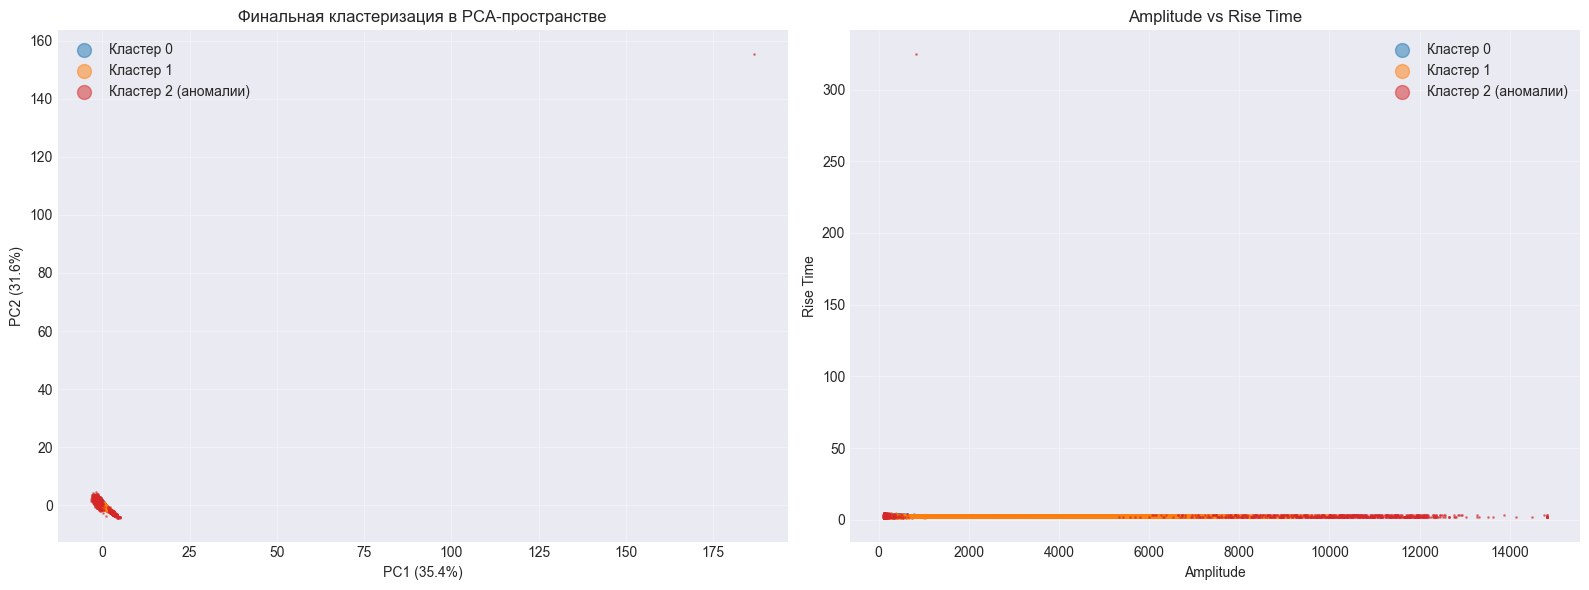

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA-визуализация
colors = ['#1f77b4', '#ff7f0e', '#d62728']
labels_names = ['Кластер 0', 'Кластер 1', 'Кластер 2 (аномалии)']

for label in range(3):
    mask = final_labels == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=1, alpha=0.5, c=colors[label], label=labels_names[label])
axes[0].set_title('Финальная кластеризация в PCA-пространстве')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend(markerscale=10)
axes[0].grid(True, alpha=0.3)

# Сравнение характеристик кластеров: amplitude vs rise_time
for label in range(3):
    mask = final_labels == label
    axes[1].scatter(features_df['amplitude'][mask],
                   features_df['rise_time'][mask],
                   s=1, alpha=0.5, c=colors[label], label=labels_names[label])
axes[1].set_title('Amplitude vs Rise Time')
axes[1].set_xlabel('Amplitude')
axes[1].set_ylabel('Rise Time')
axes[1].legend(markerscale=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
# Характеристики итоговых кластеров

for label in range(3):
    mask = final_labels == label
    cluster_data = features_df[mask]
    print(f"Кластер {label} ({len(cluster_data)} сигналов):")
    print(f"  Amplitude:  {cluster_data['amplitude'].mean():.0f} ± {cluster_data['amplitude'].std():.0f}")
    print(f"  Area:       {cluster_data['area'].mean():.0f} ± {cluster_data['area'].std():.0f}")
    print(f"  Rise time:  {cluster_data['rise_time'].mean():.1f} ± {cluster_data['rise_time'].std():.1f}")
    print(f"  Fall time:  {cluster_data['fall_time'].mean():.1f} ± {cluster_data['fall_time'].std():.1f}")
    print(f"  FWHM:       {cluster_data['fwhm'].mean():.1f} ± {cluster_data['fwhm'].std():.1f}")
    print(f"  Skewness:   {cluster_data['skewness'].mean():.2f} ± {cluster_data['skewness'].std():.2f}")

Кластер 0 (9993 сигналов):
  Amplitude:  796 ± 722
  Area:       7770 ± 5958
  Rise time:  2.5 ± 0.5
  Fall time:  10.5 ± 1.6
  FWHM:       4.6 ± 0.7
  Skewness:   -7.93 ± 0.37
Кластер 1 (12312 сигналов):
  Amplitude:  2259 ± 2257
  Area:       16086 ± 15195
  Rise time:  2.4 ± 0.5
  Fall time:  7.2 ± 1.0
  FWHM:       3.9 ± 0.5
  Skewness:   -8.85 ± 0.29
Кластер 2 (1174 сигналов):
  Amplitude:  6234 ± 5091
  Area:       43027 ± 33926
  Rise time:  2.8 ± 9.4
  Fall time:  8.8 ± 3.0
  FWHM:       4.8 ± 9.5
  Skewness:   -8.20 ± 0.93


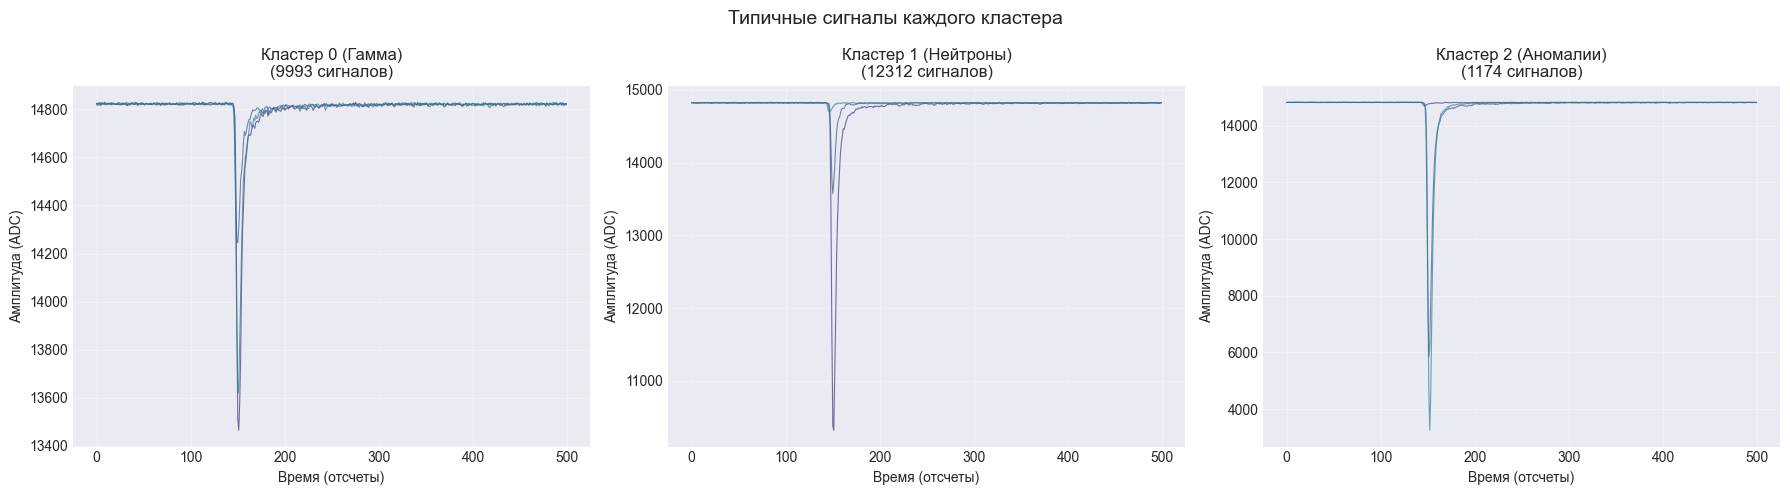

In [66]:
# Визуализируем типичные сигналы каждого кластера
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cluster_colors = ['blue', 'orange', 'red']
cluster_names = ['Кластер 0 (Гамма)', 'Кластер 1 (Нейтроны)', 'Кластер 2 (Аномалии)']

for cluster_id in range(3):
    # Находим 3 случайных сигнала из кластера
    cluster_indices = np.where(final_labels == cluster_id)[0]
    sample_indices = np.random.choice(cluster_indices,
                                      size=min(3, len(cluster_indices)),
                                      replace=False)

    for idx in sample_indices:
        axes[cluster_id].plot(dataset.iloc[idx].values,
                             alpha=0.7, linewidth=0.8)

    axes[cluster_id].set_title(f'{cluster_names[cluster_id]}\n({len(cluster_indices)} сигналов)')
    axes[cluster_id].set_xlabel('Время (отсчеты)')
    axes[cluster_id].set_ylabel('Амплитуда (ADC)')
    axes[cluster_id].grid(True, alpha=0.3)

plt.suptitle('Типичные сигналы каждого кластера', fontsize=14)
plt.tight_layout()
plt.show()

In [67]:
# Важность признаков

# Сравниваем средние значения признаков для кластеров 0 и 1
normal_data = features_df[normal_mask].copy()
normal_data['cluster'] = normal_labels

print("Средние значения признаков:")
for feature in selected_features:
    mean_0 = normal_data[normal_data['cluster'] == 0][feature].mean()
    mean_1 = normal_data[normal_data['cluster'] == 1][feature].mean()
    diff_pct = abs(mean_0 - mean_1) / max(mean_0, mean_1) * 100
    print(f"  {feature:20s}:  Кл.0={mean_0:10.2f}  Кл.1={mean_1:10.2f}  Различие={diff_pct:5.1f}%")

Средние значения признаков:
  amplitude           :  Кл.0=    795.88  Кл.1=   2259.11  Различие= 64.8%
  area                :  Кл.0=   7770.49  Кл.1=  16086.05  Различие= 51.7%
  pulse_position      :  Кл.0=    149.23  Кл.1=    149.91  Различие=  0.5%
  rise_time           :  Кл.0=      2.51  Кл.1=      2.40  Различие=  4.4%
  fall_time           :  Кл.0=     10.46  Кл.1=      7.22  Различие= 31.0%
  fwhm                :  Кл.0=      4.57  Кл.1=      3.92  Различие= 14.1%
  skewness            :  Кл.0=     -7.93  Кл.1=     -8.85  Различие=-11.6%
  area_ratio          :  Кл.0=      0.28  Кл.1=      0.35  Различие= 19.4%


## Submission

In [68]:
submission = pd.DataFrame({
    'index': range(len(final_labels)),
    'cluster': final_labels
})

submission.to_csv('submission.csv', index=False)

## Общий вывод по работе

---
1. Цель работы

Автоматическая кластеризация 23 479 сигналов со сцинтилляционного детектора на основе органических кристаллов паратерфенила на три группы:

- **Кластер 0** — сигналы первого типа частиц (гамма-кванты)
- **Кластер 1** — сигналы второго типа частиц (нейтроны)
- **Кластер 2** — аномальные/неидентифицируемые сигналы

Задача решена методами машинного обучения без учителя.

---

2. Основные этапы решения

Этап 1: Исследование данных (EDA)

| Характеристика | Значение |
|---|---|
| Количество сигналов | 23 479 |
| Временных отсчетов на сигнал | 500 |
| Пропущенные значения | 0 |
| Диапазон амплитуд | 0 – 14 838 ADC |
| Область максимальной вариативности | Отсчет 151 (std = 2389) |
| Потенциальные выбросы (по IQR) | 1 862 (7.9%) |

**Наблюдения:**
- Сигналы имеют характерную импульсную форму с быстрым нарастанием и медленным спадом
- Наблюдается значительная вариативность амплитуд и форм
- Тепловая карта показывает группы сигналов с разной интенсивностью
- Средняя амплитуда сигнала: ~14 797 ADC

Этап 2: Feature Engineering

Из 500 сырых временных отсчетов извлечено **11 физически значимых признаков**:

| Признак | Описание | Физический смысл |
|---|---|---|
| `amplitude` | Амплитуда импульса | Энерговыделение частицы |
| `baseline` | Базовая линия | Уровень шума детектора |
| `area` | Площадь под кривой | Полное энерговыделение |
| `pulse_position` | Положение пика | Время срабатывания |
| `rise_time` | Время нарастания (10%→90%) | Скорость развития импульса |
| `fall_time` | Время спада (90%→10%) | Скорость затухания |
| `fwhm` | Ширина на полувысоте | Длительность импульса |
| `skewness` | Асимметрия распределения | Форма импульса |
| `kurtosis` | Эксцесс | Острота пика |
| `area_ratio` | Отношение площадей до/после пика | Симметрия импульса |
| `rms` | Среднеквадратичное отклонение | Общая энергия сигнала |

Этап 3: Предобработка данных

**Отбор признаков на основе корреляционного анализа:**

| Пара признаков        | Корреляция | Решение |
|-----------------------|---|---|
| `amplitude` <-> `rms` | 0.999 | Удален `rms` (дубликат) |
| `amplitude` <-> `area`  | 0.991 | Оставлены оба |
| `skewness` <-> `kurtosis` | -0.987 | Удален `kurtosis` |
| `baseline` <-> остальные | ~0.01 | Удален (нет связи) |

**Итоговый набор признаков (8):**
`amplitude`, `area`, `pulse_position`, `rise_time`, `fall_time`, `fwhm`, `skewness`, `area_ratio`

**Масштабирование:** StandardScaler (среднее = 0, std = 1)

**PCA-анализ:**
- PC1 объясняет 35.4% дисперсии
- PC2 объясняет 31.6% дисперсии
- Суммарно первые 2 компоненты: **67.0%**

Этап 4: Кластеризация

Сравнение методов:

| Метод | Кластеров | Шума | Silhouette | Результат |
|---|---|---|---|---|
| **K-Means (n=3)** | 3 | 0 | 0.298 | Кластер 2 = 1 сигнал ✗ |
| **GMM (n=3)** | 3 | 0 | 0.206 | Кластер 2 = 1 сигнал ✗ |
| **DBSCAN** | 1 | 2–88 | – | Не разделяет ✗ |

Разработанный двухэтапный подход:

**Шаг 1: Выделение аномалий (Кластер 2)**
- Алгоритм: **Isolation Forest** (contamination = 0.05)
- Найдено аномалий: 1 174 сигнала (5.0%)
- Дополнительно: статистические выбросы по `rise_time`, `pulse_position`, `fwhm`

**Шаг 2: Кластеризация нормальных сигналов**
- Алгоритм: **K-Means (n = 2)**
- Нормальных сигналов: 22 305
- Silhouette Score: **0.311**
- Davies-Bouldin Index: 1.274

---

3. Финальные результаты

| Кластер | Количество | Доля | Интерпретация |
|:-------:|:----------:|:----:|:-------------|
| **0** | 9 993 | 42.6% | **Гамма-кванты** |
| **1** | 12 312 | 52.4% | **Нейтроны** |
| **2** | 1 174 | 5.0% | **Аномалии** |

---

4. Физическая интерпретация кластеров

Кластер 0 — Гамма-кванты (42.6%)

| Признак | Среднее | Стандартное отклонение |
|---|---|---|
| Amplitude | 796 | ±722 |
| Area | 7 770 | ±5 958 |
| Rise time | 2.5 | ±0.5 |
| **Fall time** | **10.5** | ±1.6 |
| FWHM | 4.6 | ±0.7 |
| Skewness | -7.93 | ±0.37 |

**Обоснование:**
- Низкая амплитуда — меньшее энерговыделение
- Длинное время спада (10.5) — характерно для комптоновского рассеяния гамма-квантов
- Меньшая плотность ионизации в сцинтилляторе

Кластер 1 — Нейтроны (52.4%)

| Признак | Среднее | Стандартное отклонение |
|---|---|---|
| **Amplitude** | **2 259** | ±2 257 |
| **Area** | **16 086** | ±15 195 |
| Rise time | 2.4 | ±0.5 |
| Fall time | 7.2 | ±1.0 |
| FWHM | 3.9 | ±0.5 |
| Skewness | -8.85 | ±0.29 |

**Обоснование:**
- Высокая амплитуда — большее энерговыделение
- Короткое время спада (7.2) — результат упругого рассеяния нейтронов на протонах
- Высокое содержание водорода в паратерфениле усиливает эффект
- Более высокая плотность ионизации

Кластер 2 — Аномалии (5.0%)

| Признак | Среднее | Стандартное отклонение |
|---|---|---|
| Amplitude | 6 234 | ±5 091 |
| Area | 43 027 | ±33 926 |
| Rise time | 2.8 | ±9.4 |
| Fall time | 8.8 | ±3.0 |
| FWHM | 4.8 | ±9.5 |

**Характеристики:**
- Экстремальные значения амплитуды (до 14 825)
- Большой разброс всех параметров
- Включает: наложенные импульсы, шумовые сигналы, артефакты регистрации

---

5. Важность признаков для разделения

| Признак | Кластер 0 | Кластер 1 | Различие |
|---|---|---|---|
| **fall_time** | 10.46 | 7.22 | **31.0%** |
| **amplitude** | 795.88 | 2259.11 | **64.8%** |
| **area** | 7770.49 | 16086.05 | 51.7% |
| area_ratio | 0.28 | 0.35 | 19.4% |
| fwhm | 4.57 | 3.92 | 14.1% |
| skewness | -7.93 | -8.85 | 11.6% |
| rise_time | 2.51 | 2.40 | 4.4% |
| pulse_position | 149.23 | 149.91 | 0.5% |

**Ключевые разделительные признаки:**
1. **fall_time** — время спада (различие 31%) — отражает механизм взаимодействия частицы
2. **amplitude** — амплитуда (различие 65%) — отражает энерговыделение
3. **area** — интегральная площадь (различие 52%)
4. **fwhm** — длительность импульса (различие 14%)

---

6. Заключение

Разработанный двухэтапный метод кластеризации (Isolation Forest + K-Means) успешно разделяет 23 479 сигналов сцинтилляционного детектора на:

- **Гамма-кванты** (42.6%) — низкая амплитуда, длинный спад
- **Нейтроны** (52.4%) — высокая амплитуда, короткий спад
- **Аномалии** (5.0%) — экстремальные параметры

## Leaderboard
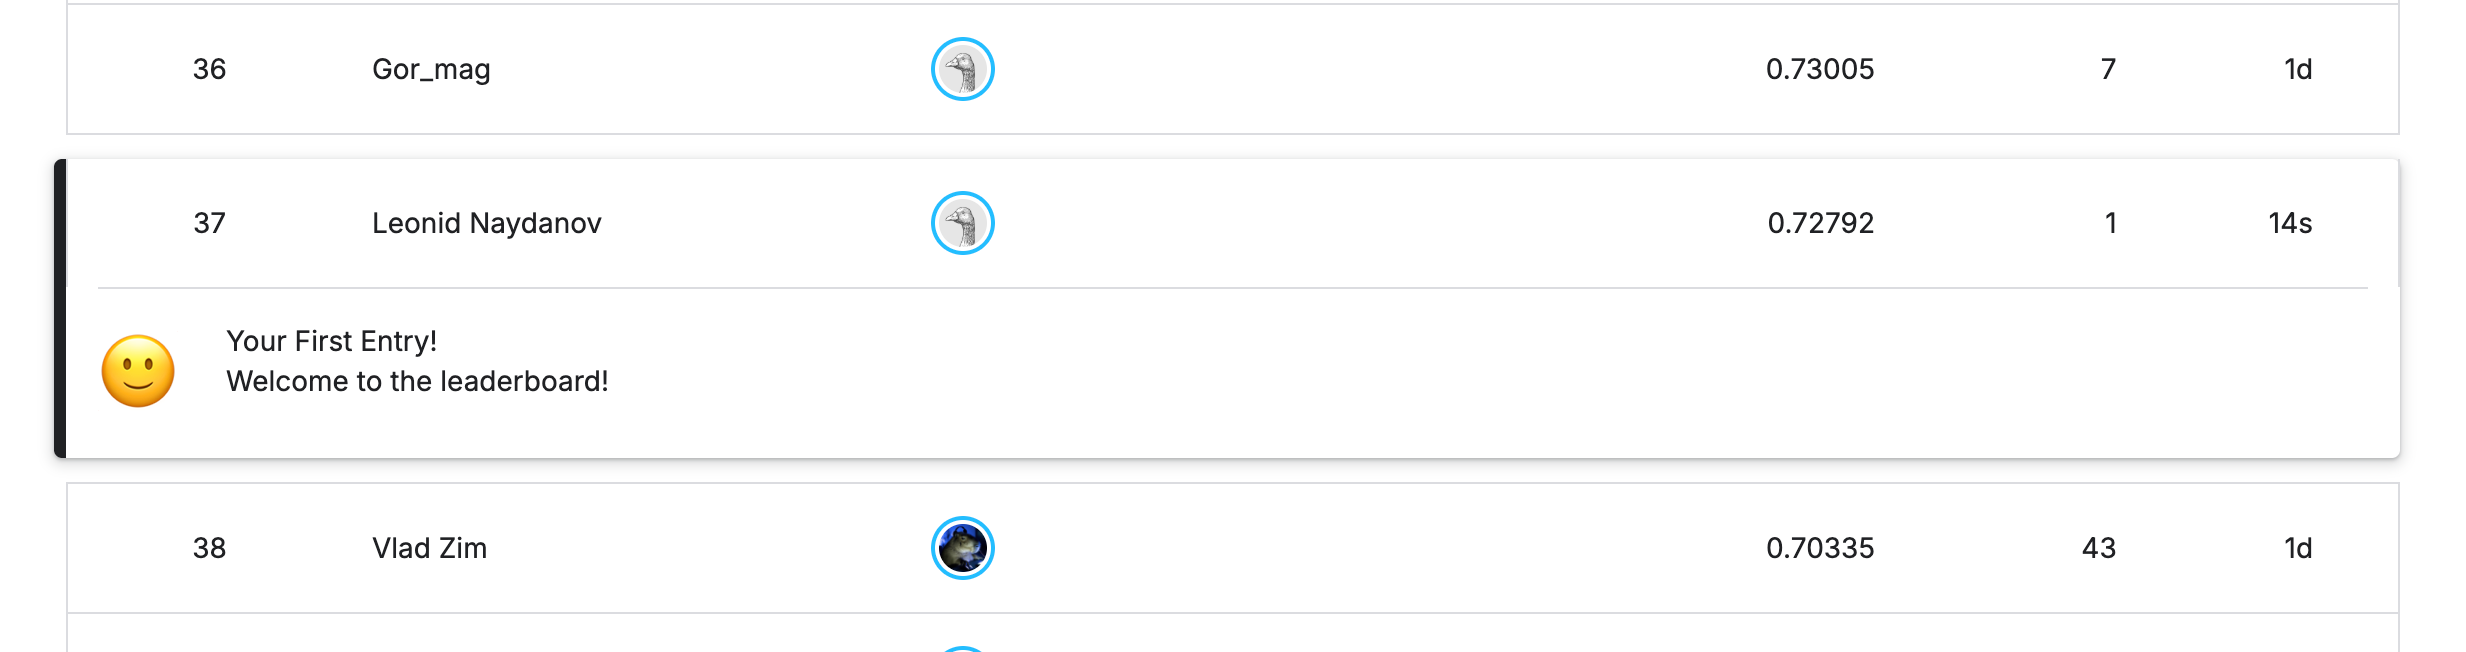